In [1]:
import os

import glob

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import matplotlib.cm as cm
import matplotlib.colors as mcolors


import sunpy
import sunpy.map
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.time import Time
from astropy.visualization import ImageNormalize, SqrtStretch


from sunpy.physics.differential_rotation import differential_rotate
from scipy.ndimage import gaussian_filter1d, median_filter, zoom
import sunpy.coordinates  # NOQA
from sunpy.net import Fido
from sunpy.net import attrs as a

import cmasher as cmr

import sys
sys.path.insert(0, '..')
from scripts.helpers import find_closest_hmi,find_closest_aia
from scripts.ribbon_map import RibbonMap as RM
from scripts.ribbon_map import RibbonCoords as RC
from scripts.ribbon_map import iris_reproject

In [2]:
import scienceplots
from sunpy.visualization.colormaps import color_tables as ct
plt.rcParams.update({'font.size': 14})
plt.style.use(['bright'])
# plt.rcParams['font.family'] = 'Atkinson Hyperlegible Next'
sdoaia1600 = ct.aia_color_table(1600*u.angstrom)
sji1400cm = ct.iris_sji_color_table('1400')

In [3]:
hmi_files=sorted(glob.glob("/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/HMI/*fits"))
aia_files=sorted(glob.glob("/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/AIA/*fits"))
SJI_files=sorted(glob.glob("/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/SJI/*fits"))

2026-07-14 09:50:47 - sunpy - WARNING: SunpyUserWarning: Using 'time' assumes an Earth-based observer.
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/re

NameError: name 'rmap_crop' is not defined

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

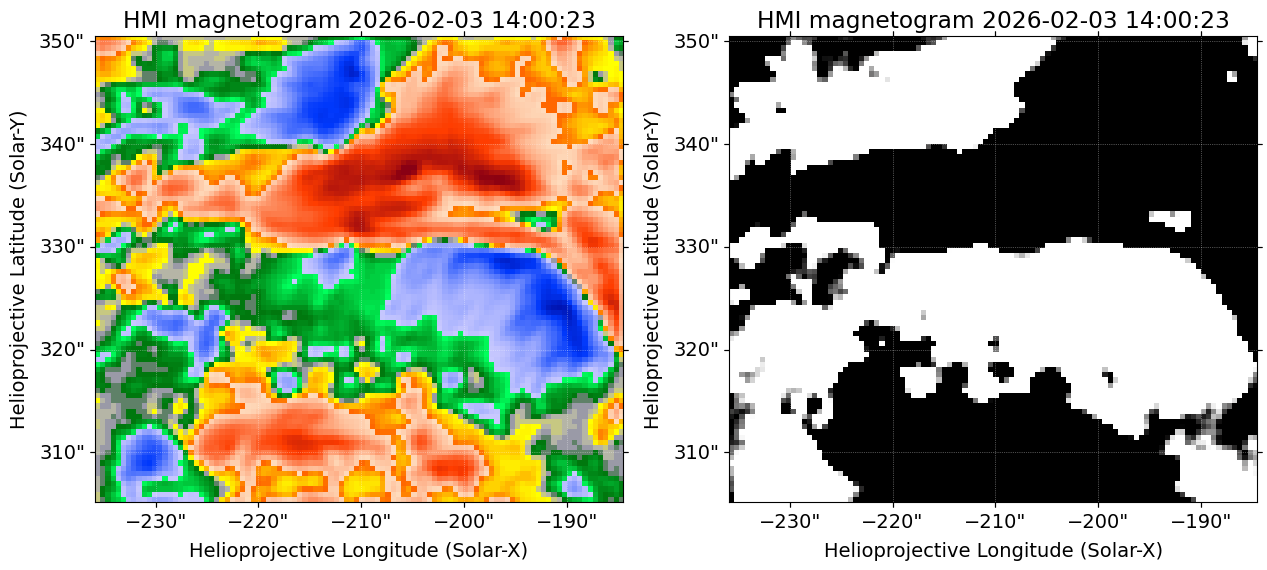

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


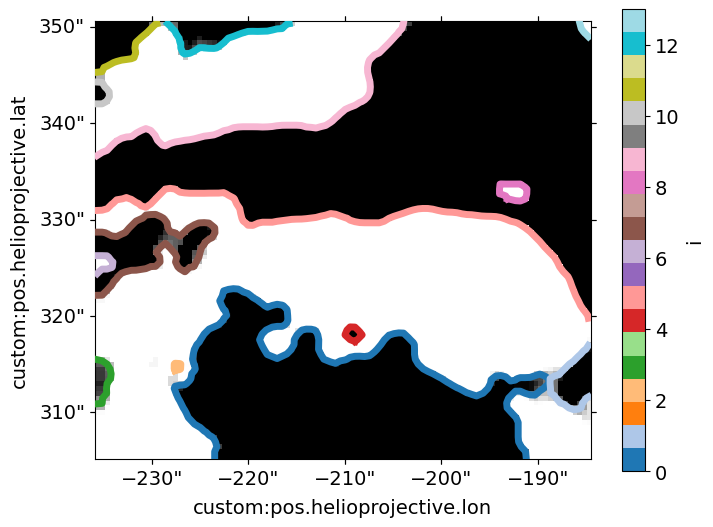

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


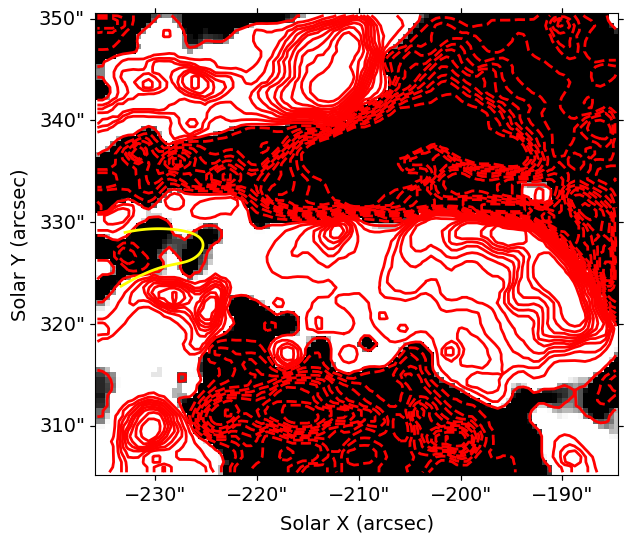

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: Ru

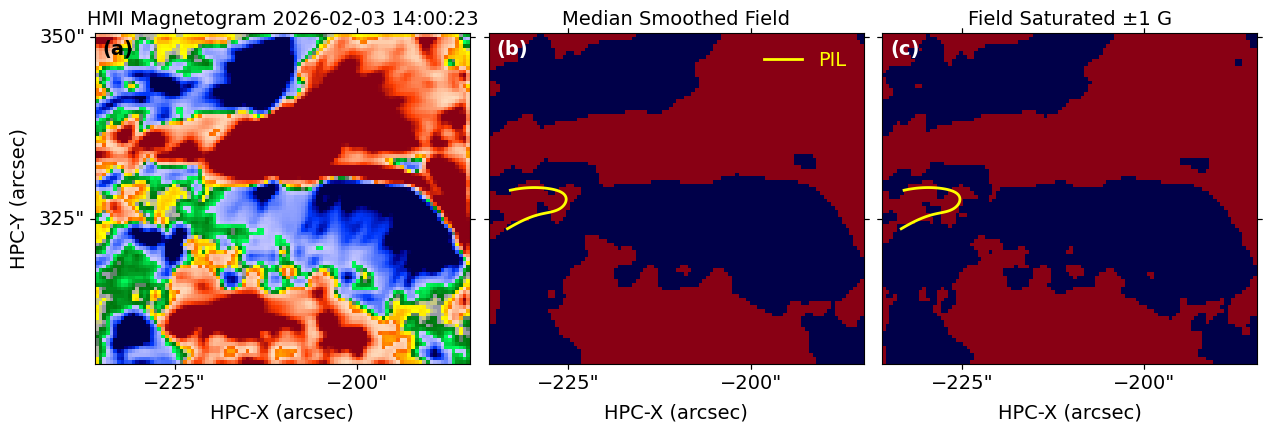

/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/kyba3549/reu/reconnection-mapping-reu/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


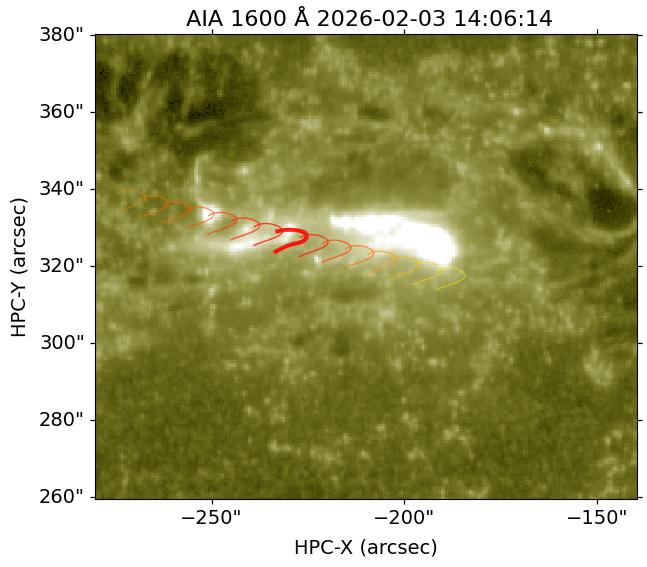

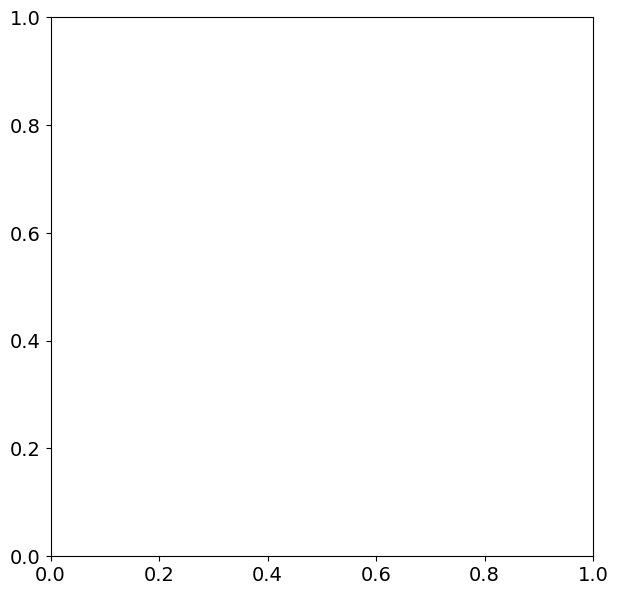

In [5]:
for i, file in enumerate(hmi_files[0:3]):
    # Hmap plotting
    hmap = sunpy.map.Map(file)
    hmap = hmap.rotate(order=3)

    xl, xr, yb, yt = -185, -236, 305, 350

    xlims_world = [xl, xr]*u.arcsec 
    ylims_world = [yb, yt]*u.arcsec

    lb = SkyCoord(xlims_world[0],ylims_world[0],frame=hmap.coordinate_frame)
    tr = SkyCoord(xlims_world[1],ylims_world[1],frame=hmap.coordinate_frame)

    hmap = hmap.submap(lb, top_right=tr)
    hmap = differential_rotate(hmap, time=hmap.date)


    # --------------- Plot ---------------
    fig = plt.figure(figsize=(15,8))

    ax = fig.add_subplot(121, projection=hmap)
    hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-1500.0, vmax=1500.0)

    ax = fig.add_subplot(122, projection=hmap)
    hmap.plot(axes=ax, cmap=cmr.neutral, norm=None, vmin=-10.0, vmax=10.0)

    fig.savefig(f"/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/hmap/ hmap {i}.png")

    # PIL finding

    smoothed = median_filter(hmap.data, size=4) 
    smooth_map = sunpy.map.Map(smoothed, hmap.meta)

    hmi_PIL = smooth_map.find_contours(0 * u.G)
    ihmax = np.argmax([h.shape[0] for h in hmi_PIL])

    # pil = hmi_PIL[ihmax]
    pil = hmi_PIL[5]

    norm=mcolors.Normalize(vmin=0.0, vmax=len(hmi_PIL)-1)
    cmap =cm.tab20

    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': smooth_map})
    im = ax.imshow(smoothed, origin='lower', cmap="Greys_r", vmin=-10.0, vmax=10.0)

    for i in range(len(hmi_PIL)):
        ax.plot_coord(hmi_PIL[i], color=cmap(norm(i)), linewidth=5)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # required but unused
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("i")

    fig.savefig(f"/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/PIL_finder/ PIL_finder {i}.png")

    # HMI Contouring and PIL smoothing

    smoothed = median_filter(hmap.data, size=4) 
    smooth_map = sunpy.map.Map(smoothed, hmap.meta)

    hmi_PIL = smooth_map.find_contours(0 * u.G)
    ihmax = np.argmax([h.shape[0] for h in hmi_PIL])

    # pil = hmi_PIL[ihmax]
    pil = hmi_PIL[7]
    tx_smooth = gaussian_filter1d(pil.Tx.arcsec, sigma=10)
    ty_smooth = gaussian_filter1d(pil.Ty.arcsec, sigma=10)

    hmi_PIL_smooth = SkyCoord(tx_smooth * u.arcsec, ty_smooth * u.arcsec,
                          frame=smooth_map.coordinate_frame)

    hmi_arcsec = np.column_stack([hmi_PIL_smooth.Tx.arcsec, hmi_PIL_smooth.Ty.arcsec])
    np.savetxt('auxiliary_data/hmi_pil_world_median.csv', hmi_arcsec, delimiter=',', header='Tx_arcsec,Ty_arcsec')


    # --------------- Plot ---------------
    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': smooth_map})
    im = ax.imshow(smoothed, origin='lower', cmap=cmr.neutral, vmin=-10.0, vmax=10.0)

    plt.contour(smoothed, levels=np.linspace(-1000, 1000, 21), colors='red', linewidths=2)
    ax.plot_coord(hmi_PIL_smooth,color='yellow', linewidth=2)

    ax.set_ylabel('Solar Y (arcsec)')
    ax.set_xlabel('Solar X (arcsec)')

    fig.savefig(f"/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/hmap_PIL_contour/ hmap_PIL_contour {i}.png")

    # HMI and PIL plotting and smoothing

    fig = plt.figure(figsize=(15, 8))


    ax = fig.add_subplot(131, projection=hmap)
    hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-500.0, vmax=500.0)
    ax.set_xlabel('HPC-X (arcsec)')
    ax.set_ylabel('HPC-Y (arcsec)')
    ax.set_title(f'HMI Magnetogram {hmap.date.strftime("%Y-%m-%d %H:%M:%S")}', fontsize=14)
    ax.grid(False)
    ax.coords[0].set_ticks(spacing=25 * u.arcsec)   
    ax.coords[1].set_ticks(spacing=25 * u.arcsec)  
    ax.text(0.02, 0.98, '(a)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='black', fontweight='bold')

    ax = fig.add_subplot(132, projection=smooth_map)
    im = ax.imshow(smoothed, origin='lower', cmap="hmimag", vmin=-.001, vmax=0.001)
    ax.coords[1].set_ticklabel_visible(False)
    ax.coords[1].set_axislabel('')
    ax.set_xlabel('HPC-X (arcsec)')
    ax.set_title('Median Smoothed Field', fontsize=14)
    ax.plot_coord(hmi_PIL_smooth, color='yellow', linewidth=2, label='PIL')
    ax.legend(loc='upper right', frameon=False, labelcolor='yellow')
    ax.coords[0].set_ticks(spacing=25 * u.arcsec)  
    ax.coords[1].set_ticks(spacing=25 * u.arcsec)  
    ax.text(0.02, 0.98, '(b)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='white', fontweight='bold')

    ax = fig.add_subplot(133, projection=hmap)
    hmap.plot(axes=ax, cmap="hmimag", norm=None, vmin=-.001, vmax=0.001)
    ax.coords[1].set_ticklabel_visible(False)
    ax.coords[1].set_axislabel('')
    ax.set_xlabel('HPC-X (arcsec)')
    ax.set_title('Field Saturated ±1 G', fontsize=14)
    ax.plot_coord(hmi_PIL_smooth, color='yellow', linewidth=2)
    ax.grid(False)
    ax.coords[0].set_ticks(spacing=25 * u.arcsec)   
    ax.coords[1].set_ticks(spacing=25 * u.arcsec)  
    ax.text(0.02, 0.98, '(c)', transform=ax.transAxes, fontsize=14,
        va='top', ha='left', color='white', fontweight='bold')

    plt.subplots_adjust(wspace=0.05)
    plt.savefig(f"/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/HMI_PIL_smoothing/ hmap_PIL_smoothing {i}.pdf", dpi=300, bbox_inches='tight')
    
    # Plotting PIL on AIA 1600 Å

    ref_map = sunpy.map.Map(aia_files[i])

    xl, xr, yb, yt = -140, -280, 260, 380 # larger FOV to capture more of the ribbons

    xlims_world = [xl, xr]*u.arcsec #small
    ylims_world = [yb, yt]*u.arcsec

    lb = SkyCoord(xlims_world[0],ylims_world[0],frame=ref_map.coordinate_frame)
    tr = SkyCoord(xlims_world[1],ylims_world[1],frame=ref_map.coordinate_frame)

    amap = ref_map.submap(lb, top_right=tr)

    
    pil_world = SkyCoord(hmi_arcsec[:,0]*u.arcsec, hmi_arcsec[:,1]*u.arcsec, 
                     frame=ref_map.coordinate_frame)
    separations = pil_world[1:].separation(pil_world[:-1]).to(u.arcsec)

    arcsec = np.concatenate([[0], np.cumsum(separations.value)]) * u.arcsec
    intensity = sunpy.map.sample_at_coords(amap, pil_world)


    rmap,xarc,yarc = RM(amap, pil_world, xoffsets=[-45, 45], diff_rotate=True, ref_map=ref_map)
    slice_coords, cross_arcsec = RC(amap, pil_world, xoffsets=[-45, 45], diff_rotate=True, ref_map=ref_map)


    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(projection=amap)
    amap.plot(axes=ax,vmax=np.percentile(amap.data, 99))
    ax.grid(False)
    ax.set_title(f' AIA 1600 Å {amap.date.strftime("%Y-%m-%d %H:%M:%S")}', fontsize=16)
    ax.set_xlabel('HPC-X (arcsec)')
    ax.set_ylabel('HPC-Y (arcsec)')

    ax.plot_coord(pil_world, linewidth=3, color='red',alpha=0.8)

    center_idx = np.argmin(np.abs(cross_arcsec))  # index where offset ≈ 0
    start = center_idx % 10                        # shift so center_idx lands in the sample
    slices = slice_coords[start::10]
    mid = (center_idx - start) // 10              # index of offset=0 within `slices`

    for i, sc in enumerate(slices):
        t = abs(i - mid) / max(mid, len(slices) - 1 - mid)
        lw = 1.4 - 0.8 * t
        alpha = 0.85 - 0.45 * t
        if i <= mid:
            frac = (mid - i) / max(mid, 1)
            color = (1.0, 0.55 * frac, 0.0)
        else:
            frac = (i - mid) / max(len(slices) - 1 - mid, 1)
            color = (1.0, frac, 0.0)
        ax.plot_coord(sc, linewidth=1.0, color=color, alpha=alpha)
    fig.savefig(f"/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/PIL_on_amap/ PIL_on_amap {i}.pdf")

    # HMI intensity mapping along the PIL

    fig, ax = plt.subplots(figsize=(7, 7))  

    ax.imshow(rmap_crop.T, aspect='auto', origin='lower',
          extent=[yarc[0], yarc[-1], xarc_crop[0], xarc_crop[-1]],  # swapped
          cmap=sdoaia1600, vmin=400, vmax=10000, interpolation='None', alpha=0.5)

    vlim = np.nanpercentile(np.abs(np.concatenate([mean_hmi_ab[xl:xr], mean_hmi_cd[xl:xr]])), 95)
    norm = Normalize(vmin=-vlim, vmax=vlim)
    cmap_b = cmr.fusion

    overlay = np.zeros((*rmap_crop.T.shape, 4))  
    for i, idx in enumerate(range(xl, xr)):
        if np.isnan(a_arr[idx]):
            continue
        a, b, c, d = int(a_arr[idx]), int(b_arr[idx]), int(c_arr[idx]), int(d_arr[idx])
        overlay[i, b:a+1] = (*cmap_b(norm(mean_hmi_ab[idx]))[:3], 0.99)  
        overlay[i, d:c+1] = (*cmap_b(norm(mean_hmi_cd[idx]))[:3], 0.99)

    ax.imshow(overlay, aspect='auto', origin='lower',
          extent=[yarc[0], yarc[-1], xarc_crop[0], xarc_crop[-1]],  
          interpolation='None')

    ax.set_ylabel('PIL-Y (arcsec)')
    ax.set_xlabel('PIL-X (arcsec)')

    ax.axvline(0, color='white', linestyle='--', label='PIL',alpha=0.5)

    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap_b),
             ax=ax, label=r'$\langle B \rangle$ [G]', pad=0.01)
    ax.legend(fontsize=12, frameon=False, labelcolor='white', loc='lower left')

    contours = ax.contour(rmap_crop.T, levels=[7500],
                      extent=[yarc[0], yarc[-1], xarc_crop[0], xarc_crop[-1]],
                      colors='grey', linewidths=1.5, alpha=0.7,
                      origin='lower')

    ax.set_xlim(-38) 
    ax.invert_yaxis()
    
    fig.savefig(f'/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/hmap_intensity_stretched/ {amap.date.iso}.pdf', dpi=300, bbox_inches='tight')

    # Ribbons mapped along PIL

    hmap = sunpy.map.Map(file)
    hmap = hmap.rotate(order=3)

    xlims_world = [xl, xr]*u.arcsec 
    ylims_world = [yb, yt]*u.arcsec

    lb = SkyCoord(xlims_world[0],ylims_world[0],frame=hmap.coordinate_frame)
    tr = SkyCoord(xlims_world[1],ylims_world[1],frame=hmap.coordinate_frame)

    hmap = hmap.submap(lb, top_right=tr)

    hmi_warped,h_xarc,h_yarc = RM(hmap, pil_world, xoffsets=[-45, 45], diff_rotate=False)

    zoom_factors = (rmap.shape[0] / hmi_warped.shape[0], rmap.shape[1] / hmi_warped.shape[1])
    hmi_warped_interp = zoom(hmi_warped, zoom_factors, order=3)

    print(hmi_warped.shape, '->', hmi_warped_interp.shape, '(target:', rmap.shape, ')')
    
    zero_idx = np.argmin(np.abs(yarc))

    def fwhm_bounds(prof, offset=0):
        peak_i = np.argmax(prof)
        half = prof[peak_i] / 2
        lo = peak_i
        while lo > 0 and prof[lo] > half:
            lo -= 1
        hi = peak_i
        while hi < len(prof) - 1 and prof[hi] > half:
            hi += 1
        return lo + offset, hi + offset

    n_cols = rmap.shape[1]
    a_arr, b_arr, c_arr, d_arr, mean_hmi_ab, mean_hmi_cd = [np.full(n_cols, np.nan) for _ in range(6)]

    for idx in range(n_cols):
        profile = rmap[:, idx]

        d, c = fwhm_bounds(profile[:zero_idx])
        b, a = fwhm_bounds(profile[zero_idx:], zero_idx)

        a_arr[idx] = a
        b_arr[idx] = b
        c_arr[idx] = c
        d_arr[idx] = d
        mean_hmi_ab[idx] = np.median(hmi_warped_interp[b:a+1, idx])  # upper ribbon
        mean_hmi_cd[idx] = np.median(hmi_warped_interp[d:c+1, idx])  # lower ribbon
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(rmap, aspect='auto', origin='lower',
          extent=[0, xarc[-1], yarc[0], yarc[-1]],
          cmap=sdoaia1600, vmin=300, vmax=10000, interpolation='None')
    vlim = np.nanpercentile(np.abs(np.concatenate([mean_hmi_ab, mean_hmi_cd])), 99)
    norm = Normalize(vmin=-vlim, vmax=vlim)
    cmap_b = cmr.fusion
    
    overlay = np.zeros((*rmap.shape, 4))
    for idx in range(rmap.shape[1]):
        if np.isnan(a_arr[idx]):
            continue
        a, b, c, d = int(a_arr[idx]), int(b_arr[idx]), int(c_arr[idx]), int(d_arr[idx])
        overlay[b:a+1, idx] = (*cmap_b(norm(mean_hmi_ab[idx]))[:3], 0.95)
        overlay[d:c+1, idx] = (*cmap_b(norm(mean_hmi_cd[idx]))[:3], 0.95)
        
        ax.imshow(overlay, aspect='auto', origin='lower',
          extent=[0, xarc[-1], yarc[0], yarc[-1]], interpolation='None')

    ax.axhline(0, color='white', linestyle='--', alpha=0.5, label='PIL')
    ax.set_xlabel('x (arcsec)')
    ax.set_ylabel('y (arcsec)')


    # --------------- Plot ---------------
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap_b),
             ax=ax, label=r'$\langle B \rangle$ [G]', pad=0.01)
    ax.legend(fontsize=8)

    # # show extent ribbon locations, cropped region
    # xl,xr = 12, 50

    # ax.axvline(xarc[xl], color='cyan', linestyle='--', label='xl')
    # ax.axvline(xarc[xr], color='magenta', linestyle='--', label='xr')

    # rmap_crop = rmap[:, xl:xr]
    # xarc_crop = xarc[xl:xr]
    # xarc_crop = xarc[::-1][xl:xr]

    fig.savefig(f"/home/kyba3549/reu/reconnection-mapping-reu/reconnection_mapping/auxiliary_data/Across_time/Figures/hmap_intensity/ hmap_intensity {i}.pdf")

    